# **Beer Production Analysis**

## Import Libraries and Load Dataset

In [1]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the three csv files
states = pd.read_csv('Datasets/beer_states.csv')
brewers = pd.read_csv('Datasets/brewer_size.csv')
materials = pd.read_csv('Datasets/brewing_materials.csv')

In [4]:
# Take a look at the dataframes and understand the structure
print(states.shape)
print(brewers.shape)
print(materials.shape)

(1872, 4)
(137, 6)
(1440, 9)


In [5]:
pd.set_option("display.float_format", "{:.2f}".format)

## **1** Data Cleaning
<font color = red>[20 marks]</font> <br>

The data is mostly cleaned, but you may find a few anomalies.

#### **1.1** Fixing Columns
<font color = red>[5 marks]</font> <br>
Fix/drop any columns as you seem necessary.

#### **1.1.1** *states* table

In [6]:
# Check if there are any columns that can be dropped/fixed.
print(states.info())

print(states[['state','year', 'type']].value_counts())

# for column in states.columns:
#     print(f"{column}: {states[column].isnull().sum()}")

# print(states['barrels'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1872 entries, 0 to 1871
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   state    1872 non-null   str    
 1   year     1872 non-null   int64  
 2   barrels  1853 non-null   float64
 3   type     1872 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 88.6 KB
None
state  year  type            
AK     2008  On Premises         1
       2009  On Premises         1
       2010  On Premises         1
       2011  On Premises         1
       2012  On Premises         1
                                ..
total  2015  Kegs and Barrels    1
       2016  Kegs and Barrels    1
       2017  Kegs and Barrels    1
       2018  Kegs and Barrels    1
       2019  Kegs and Barrels    1
Name: count, Length: 1872, dtype: int64


##### SUMMARY
- Couldn't find any such column that could be dropped or fixed.

#### **1.1.2** *materials* table

In [7]:
materials['data_type'].value_counts()

data_type
Pounds of Materials Used    1440
Name: count, dtype: int64

##### Summary
- `data_type` column could be drop as for all the rows it has same value i.e., **Pounds of Materials Used**. It won't help in any prediction.

In [8]:
# Check if there are any columns that can be dropped/fixed.
print(materials.columns)
materials.drop(columns=['data_type'], inplace=True)
print(materials.columns)

Index(['data_type', 'material_type', 'year', 'month', 'type', 'month_current',
       'month_prior_year', 'ytd_current', 'ytd_prior_year'],
      dtype='str')
Index(['material_type', 'year', 'month', 'type', 'month_current',
       'month_prior_year', 'ytd_current', 'ytd_prior_year'],
      dtype='str')


#### **1.1.3** *brewers* table

In [9]:
# Check if there are any columns that can be dropped/fixed.
brewers.info()

<class 'pandas.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              137 non-null    int64  
 1   brewer_size       137 non-null    str    
 2   n_of_brewers      137 non-null    int64  
 3   total_barrels     136 non-null    float64
 4   taxable_removals  137 non-null    float64
 5   total_shipped     135 non-null    float64
dtypes: float64(3), int64(2), str(1)
memory usage: 9.6 KB


In [10]:
print(brewers.columns)
brewers['no_of_brewers'] = brewers['n_of_brewers']
brewers.drop(columns=['n_of_brewers'], inplace=True)
print(brewers.columns)

Index(['year', 'brewer_size', 'n_of_brewers', 'total_barrels',
       'taxable_removals', 'total_shipped'],
      dtype='str')
Index(['year', 'brewer_size', 'total_barrels', 'taxable_removals',
       'total_shipped', 'no_of_brewers'],
      dtype='str')


In [11]:
brewers['brewer_size'].value_counts()

brewer_size
6,000,001 Barrels and Over        11
500,001 to 1,000,000 Barrels      11
100,001 to 500,000 Barrels        11
60,001 to 100,000 Barrels         11
30,001 to 60,000 Barrels          11
15,001 to 30,000 Barrels          11
7,501 to 15,000 Barrels           11
1,001 to 7,500 Barrels            11
1 to 1,000 Barrels                11
Total                             11
2,000,000 to 6,000,000 Barrels     9
1,000,001 to 1,999,999 Barrels     9
Under 1 Barrel                     6
1,000,001 to 6,000,000 Barrels     1
1,000,000 to 6,000,000 Barrels     1
Zero Barrels                       1
Name: count, dtype: int64

##### SUMMARY
- Couldn't find any column that could be dropped.
- Column `n_of_brewers` could be renamed to `no_of_brewers`
- Every value of column `brewer_size` has a substring **Barrels** except **Total**. This substring could be removed. Further this column could further be divided into two columns `brewer_size_start` and `brewer_size_end` for better clarity.

#### **1.2** Fixing Rows
<font color = red>[5 marks]</font> <br>
Can you find rows having totals in any table? To avoid these from reflecting in the analyses, you can drop these.

#### **1.2.1** *states* table

In [12]:
# Remove rows having totals.
for column in states.columns:
    rows_containing_totals = pd.DataFrame()
    if states[column].dtype == 'str':
        rows_containing_totals = states[states[column].str.contains('Total') | states[column].str.contains('total')]
    print(f"Rows containing totals in column {column}: {rows_containing_totals.shape[0]}")

Rows containing totals in column state: 36
Rows containing totals in column year: 0
Rows containing totals in column barrels: 0
Rows containing totals in column type: 0


##### SUMMARY
- There are **36** rows having value which contains **Total/total** keywords for `state` column. Since it represents aggregated data so these rows could be removed.

In [13]:
print(states.shape)
states = states[~states['state'].str.contains('Total') & ~states['state'].str.contains('total')].reset_index(drop=True)
print(states.shape)

(1872, 4)
(1836, 4)


#### **1.2.2** *materials* table

In [14]:
for column in materials.columns:
    rows_containing_totals = pd.DataFrame()
    if materials[column].dtype == 'str':
        rows_containing_totals = materials[materials[column].str.contains('Total') | materials[column].str.contains('total')]
    print(f"Rows containing totals in column {column}: {rows_containing_totals.shape[0]}")

Rows containing totals in column material_type: 360
Rows containing totals in column year: 0
Rows containing totals in column month: 0
Rows containing totals in column type: 360
Rows containing totals in column month_current: 0
Rows containing totals in column month_prior_year: 0
Rows containing totals in column ytd_current: 0
Rows containing totals in column ytd_prior_year: 0


##### SUMMARY
- There are **360** rows having value which contains **Total/total** keywords for `material_type` and `type` columns. Since it represents aggregated data so these rows could be removed.

In [15]:
materials[((materials['material_type'].str.contains('Total') | materials['material_type'].str.contains('total')) & (materials['type'].str.contains('Total') | materials['type'].str.contains('total')))].shape

(360, 8)

##### SUMMARY
- Wherever the `material_type` column has **Total/total** keyword in the value, `type` column has also same keyword. We can drop these rows.

In [16]:
print(materials.shape)
materials = materials[~materials['material_type'].str.contains('Total') & ~materials['material_type'].str.contains('total')].reset_index(drop=True)
print(materials.shape)

(1440, 8)
(1080, 8)


#### **1.2.3** *brewers* table

In [17]:
# Remove rows having totals
for column in brewers.columns:
    rows_containing_totals = pd.DataFrame()
    if brewers[column].dtype == 'str':
        rows_containing_totals = brewers[brewers[column].str.contains('Total') | brewers[column].str.contains('total')]
    print(f"Rows containing totals in column {column}: {rows_containing_totals.shape[0]}")


Rows containing totals in column year: 0
Rows containing totals in column brewer_size: 11
Rows containing totals in column total_barrels: 0
Rows containing totals in column taxable_removals: 0
Rows containing totals in column total_shipped: 0
Rows containing totals in column no_of_brewers: 0


##### SUMMARY
- There are **11** rows having value which contains **Total/total** keywords for `brewer_size` column. Since it represents aggregated data so these rows could be removed.

In [18]:
print(brewers.shape)
brewers = brewers[~brewers['brewer_size'].str.contains('Total') & ~brewers['brewer_size'].str.contains('total')].reset_index(drop=True)
print(brewers.shape)

(137, 6)
(126, 6)


### **1.3** Handling Missing Values
<font color = red>[5 marks]</font> <br>

#### **1.3.1** *states*
<font color = red>[1 marks]</font> <br>

In [19]:
# Find the proportion of missing values in each column
states.info()
missing_barrels = states[states['barrels'].isnull()]
print(f"Missing barrels: {missing_barrels.shape[0]}")
print(f"Proportion of missing barrels: {missing_barrels.shape[0] / states.shape[0]}")
print(f"Percentage of missing barrels: {round(missing_barrels.shape[0] / states.shape[0] * 100, 2)}%")

<class 'pandas.DataFrame'>
RangeIndex: 1836 entries, 0 to 1835
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   state    1836 non-null   str    
 1   year     1836 non-null   int64  
 2   barrels  1817 non-null   float64
 3   type     1836 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 87.2 KB
Missing barrels: 19
Proportion of missing barrels: 0.010348583877995643
Percentage of missing barrels: 1.03%


##### SUMMARY
- It seems that `barrels` column has **19** missing values. This means that around **1%** of rows are there which have missing barrel values.

In [20]:
# Analyse the null values and decide what to do with them
states[states['barrels'].isna()]


,state,year,barrels,type
300,MS,2008,NaN,On Premises
624,AL,2008,NaN,Bottles and Cans
625,AL,2009,NaN,Bottles and Cans
626,AL,2010,NaN,Bottles and Cans
948,ND,2008,NaN,Bottles and Cans
949,ND,2009,NaN,Bottles and Cans
950,ND,2010,NaN,Bottles and Cans
951,ND,2011,NaN,Bottles and Cans
952,ND,2012,NaN,Bottles and Cans
1104,SD,2008,NaN,Bottles and Cans


##### SUMMARY
- Since the missing barrels are only **1%** and the rows for missing barrels seems to be mostly random. So removing these rows won't affect much to the dataset.

In [21]:
print(states.shape)
states = states[~states['barrels'].isna()].reset_index(drop=True)
print(states.shape)

(1836, 4)
(1817, 4)


#### **1.3.2** *materials*
<font color = red>[2 marks]</font> <br>

In [22]:
# Find the percentage of missing values in each column
materials.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   material_type     1080 non-null   str    
 1   year              1080 non-null   int64  
 2   month             1080 non-null   int64  
 3   type              1080 non-null   str    
 4   month_current     1080 non-null   int64  
 5   month_prior_year  1080 non-null   int64  
 6   ytd_current       756 non-null    float64
 7   ytd_prior_year    756 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 104.5 KB


There is a significant amount of missing values in some columns. Check the rows with null values.

In [23]:
# Display the rows with null values
ytd_current_missing = materials[materials['ytd_current'].isnull()]
print(f"Missing ytd_current: {ytd_current_missing.shape[0]}")
print(f"Percentage of missing ytd_current: {round(ytd_current_missing.shape[0] / materials.shape[0] * 100, 2)}%")
ytd_prior_year_missing = materials[materials['ytd_prior_year'].isnull()]
print(f"Missing ytd_prior_year: {ytd_prior_year_missing.shape[0]}")
print(f"Percentage of missing ytd_prior_year: {round(ytd_prior_year_missing.shape[0] / materials.shape[0] * 100, 2)}%")


Missing ytd_current: 324
Percentage of missing ytd_current: 30.0%
Missing ytd_prior_year: 324
Percentage of missing ytd_prior_year: 30.0%


##### SUMMARY
- It seems that columns `ytd_current` and `ytd_prior_year` have **324** missing values which is about **30%** of the entire values.

What did you find? Do you think it's beneficial to impute/drop these values? Why? Why not?

Try to find more about the missing values? Why are these missing? Can you fix those easily? How will the missing values impact your analyses?

In [24]:
missing_ytd = materials[materials['ytd_current'].isnull() & materials['ytd_prior_year'].isnull()]
print(missing_ytd.shape)
missing_ytd['year'].value_counts()

(324, 8)


year
2015    108
2016    108
2017    108
Name: count, dtype: int64

In [25]:
materials[(materials['month'] == 1) & (materials['month_current'] != materials['ytd_current']) & (~materials['ytd_current'].isnull())].head()

,material_type,year,month,type,month_current,month_prior_year,ytd_current,ytd_prior_year


In [26]:
materials[(materials['month'] == 1) & (materials['month_prior_year'] != materials['ytd_prior_year']) & (~materials['ytd_prior_year'].isnull())].head()

,material_type,year,month,type,month_current,month_prior_year,ytd_current,ytd_prior_year


##### SUMMARY
- For all the months, for year **2015**, **2016** and **2017**, `ytd_current` and `ytd_prior_year` have missing values. 
- It seems that for these three year, the value didn't got feed.
- Since the data for these three years are around 30% of entire data so we can not blindly remove them. Let us see how can we impute the values here.
- It seems that the data in `ytd_*` columns are not direct cummalitive sum of `monthly_*` columns so it can't be imputed directly. This means that we should rely more on `monthly_*` columns more that `ytd_*` columns for now.
- One more observation is that for `month = 1`, the `monthly_*` and `yearly_*` are same for every `year` for every `type`. So we can atleat impute values for this month.

In [27]:
types = materials['type'].value_counts().keys().values.tolist()

for year in [2015, 2016, 2017]:
    for type in types:
        materials.loc[(materials['month'] == 1) & (materials['year'] == year) & (materials['type'] == type), 'ytd_current'] = materials.loc[(materials['month'] == 1) & (materials['year'] == year) & (materials['type'] == type), 'ytd_current'].fillna(materials[(materials['month'] == 1) & (materials['year'] == year) & (materials['type'] == type)]['month_current'].values[0])
        materials.loc[(materials['month'] == 1) & (materials['year'] == year) & (materials['type'] == type), 'ytd_prior_year'] = materials.loc[(materials['month'] == 1) & (materials['year'] == year) & (materials['type'] == type), 'ytd_prior_year'].fillna(materials[(materials['month'] == 1) & (materials['year'] == year) & (materials['type'] == type)]['month_prior_year'].values[0])

In [28]:
# Verify the above update
missing_ytd = materials[materials['ytd_current'].isnull() & materials['ytd_prior_year'].isnull()]
print(missing_ytd.shape)
missing_ytd['year'].value_counts()

(297, 8)


year
2015    99
2016    99
2017    99
Name: count, dtype: int64

#### **1.3.3** *brewers*
<font color = red>[2 marks]</font> <br>

In [29]:
# Percentage of missing values in columns
brewers.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              126 non-null    int64  
 1   brewer_size       126 non-null    str    
 2   total_barrels     125 non-null    float64
 3   taxable_removals  126 non-null    float64
 4   total_shipped     124 non-null    float64
 5   no_of_brewers     126 non-null    int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 9.1 KB


In [30]:
missing_total_barrels = brewers[brewers['total_barrels'].isna()]
print(f"Missing total_barrels: {missing_total_barrels.shape[0]}")
print(f"Percentage of missing total_barrels: {round(missing_total_barrels.shape[0] / brewers.shape[0] * 100, 2)}%")

Missing total_barrels: 1
Percentage of missing total_barrels: 0.79%


In [31]:
missing_total_shipped = brewers[brewers['total_shipped'].isna()]
print(f"Missing total_shipped: {missing_total_shipped.shape[0]}")
print(f"Percentage of missing total_shipped: {round(missing_total_shipped.shape[0] / brewers.shape[0] * 100, 2)}%")

Missing total_shipped: 2
Percentage of missing total_shipped: 1.59%


##### SUMMARY
- Columns `total_barrels` and `total_shipped` have **0.79%** and **1.59%** of missing values respectively.

In [32]:
# Analyse the missing values and decide what to do with them
# Should you impute with mean or median? Should you drop?

In [33]:
under_1_barrel = brewers[brewers['brewer_size'] == 'Under 1 Barrel']
under_1_barrel.head(10)

,year,brewer_size,total_barrels,taxable_removals,total_shipped,no_of_brewers
10,2009,Under 1 Barrel,3.70,14711.36,119.00,195
88,2016,Under 1 Barrel,4.43,102983.40,601.00,488
100,2017,Under 1 Barrel,6.73,107494.10,503.00,553
112,2018,Under 1 Barrel,7.47,142501.39,274.00,164
124,2019,Under 1 Barrel,18.30,19432.26,NaN,28
125,2019,Under 1 Barrel,NaN,114960.27,185.00,174


In [34]:
under_1_barrel.describe()

,year,total_barrels,taxable_removals,total_shipped,no_of_brewers
count,6.00,5.00,6.00,5.00,6.00
mean,2016.33,8.13,83680.46,336.40,267.00
std,3.78,5.90,53408.97,207.27,206.01
min,2009.00,3.70,14711.36,119.00,28.00
25%,2016.25,4.43,40320.04,185.00,166.50
50%,2017.50,6.73,105238.75,274.00,184.50
75%,2018.75,7.47,113093.73,503.00,414.75
max,2019.00,18.30,142501.39,601.00,553.00


<Axes: ylabel='total_barrels'>

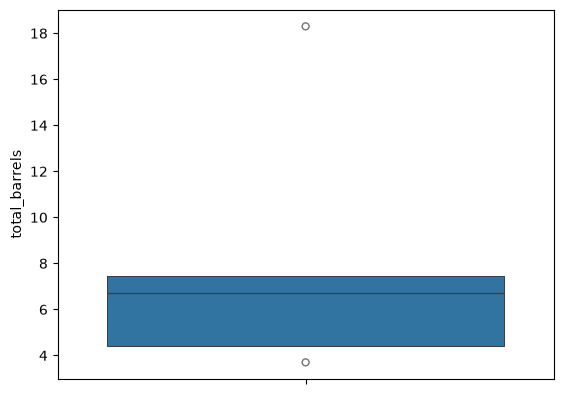

In [35]:
sns.boxenplot(under_1_barrel['total_barrels'])

<Axes: ylabel='total_shipped'>

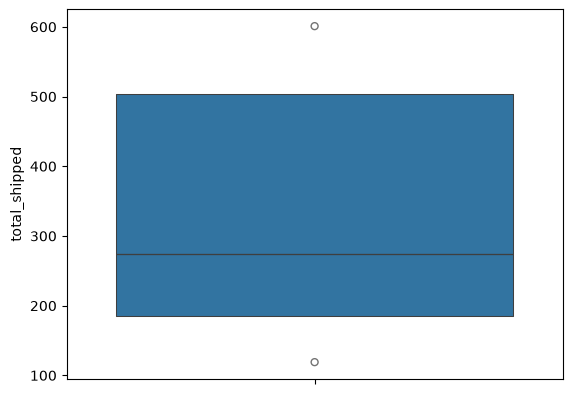

In [36]:

sns.boxenplot(under_1_barrel['total_shipped'])

##### SUMMARY
- From the above description and boxplot, it is clear that the values for `total_barrels` and `total_shipped` where `brewer_size` is **Under 1 Barrel** are left and right skewed respectively. Hence we could impute the null value of `total_barrels` and `total_shipped` with their *median* where `brewer_size` is **Under 1 Barrel**.

In [37]:
under_1_barrel_total_barrels_median = under_1_barrel['total_barrels'].median()
brewers['total_barrels'] = brewers['total_barrels'].fillna(under_1_barrel_total_barrels_median)
under_1_barrel_total_shipped_median = under_1_barrel['total_shipped'].median()
brewers.loc[brewers['brewer_size'] == 'Under 1 Barrel', 'total_shipped'] = brewers.loc[brewers['brewer_size'] == 'Under 1 Barrel', 'total_shipped'].fillna(under_1_barrel_total_shipped_median)
brewers.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              126 non-null    int64  
 1   brewer_size       126 non-null    str    
 2   total_barrels     126 non-null    float64
 3   taxable_removals  126 non-null    float64
 4   total_shipped     125 non-null    float64
 5   no_of_brewers     126 non-null    int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 9.1 KB


In [38]:
brewers[brewers['total_shipped'].isna()]

,year,brewer_size,total_barrels,taxable_removals,total_shipped,no_of_brewers
76,2015,Zero Barrels,0.00,87811.22,NaN,476


##### SUMMARY
- Now the only null value in brewers is for `total_shipped` when the `brewer_size = Zero Barrels`. We can also see that here `total_barrels` is **0.0**.

In [39]:
zero_barrel = brewers[brewers['brewer_size'] == 'Zero Barrels']
zero_barrel.head(10)

,year,brewer_size,total_barrels,taxable_removals,total_shipped,no_of_brewers
76,2015,Zero Barrels,0.00,87811.22,NaN,476


Did you notice that even though there was zero beer production for brewers of size zero barrels, the taxable removals were around 88 thousand.

Why did you think this happened? Analyse this and report the result.
<br>

*Hint*: Taxable removals are the barrels used for consumption within the country/state. These are the barrels that are sold in that year.

##### SUMMARY
- We can see that now there is only one NaN value for `total_shipped` where the value of `brewer_size` is **Zero Barrels**.
- Since it is only one row, the immidieate idea that comes is to delete it but if we delete it then we would loose the critical information of `taxable_removals` of 88K. Since we didn't find any logic to impute it's value so let us impute it with 0 and assume that the brewery didn't shipped any beer.

In [40]:
brewers.loc[brewers['brewer_size'] == 'Zero Barrels', 'total_shipped'] = brewers.loc[brewers['brewer_size'] == 'Zero Barrels', 'total_shipped'].fillna(0)
brewers.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              126 non-null    int64  
 1   brewer_size       126 non-null    str    
 2   total_barrels     126 non-null    float64
 3   taxable_removals  126 non-null    float64
 4   total_shipped     126 non-null    float64
 5   no_of_brewers     126 non-null    int64  
dtypes: float64(3), int64(2), str(1)
memory usage: 9.1 KB


### **1.4** Handling Outliers
<font color = red>[5 marks]</font> <br>

In [41]:
# Check if there are any outliers present
# Do any columns need standardising?


#### 1.4.1 states

In [42]:
states.describe()


,year,barrels
count,1817.00,1817.00
mean,2013.54,1165834.98
std,3.44,3592214.16
min,2008.00,0.00
25%,2011.00,6817.26
50%,2014.00,28681.77
75%,2017.00,176577.49
max,2019.00,24182900.40


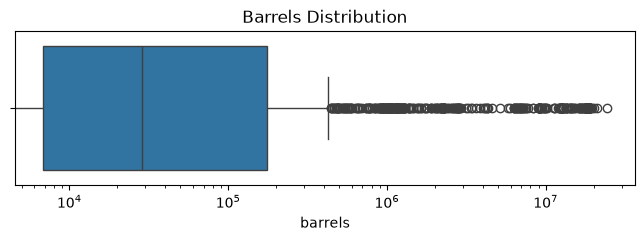

In [43]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=states['barrels'])
plt.title('Barrels Distribution')
plt.xscale('log')
plt.show()

In [44]:
Q1 = states['barrels'].quantile(0.25)
Q3 = states['barrels'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = states[states['barrels'] > upper_bound]
print(f"Outliers flagged by IQR: {len(outliers)}")
print(outliers['barrels'].describe())

Outliers flagged by IQR: 357
count        357.00
mean     5736907.16
std      6302774.00
min       442264.60
25%      1036589.35
50%      2177094.68
75%      9738023.02
max     24182900.40
Name: barrels, dtype: float64


In [45]:
states.nlargest(10, 'barrels')[['year', 'state', 'barrels', 'type']]

,year,state,barrels,type
668,2008,CO,24182900.40,Bottles and Cans
669,2009,CO,21095113.55,Bottles and Cans
656,2008,CA,20082718.48,Bottles and Cans
657,2009,CA,19452836.45,Bottles and Cans
672,2012,CO,19267902.29,Bottles and Cans
658,2010,CA,19095643.27,Bottles and Cans
1118,2009,TX,19020183.48,Bottles and Cans
1119,2010,TX,18985409.81,Bottles and Cans
660,2012,CA,18940276.02,Bottles and Cans
1120,2011,TX,18934858.19,Bottles and Cans


##### SUMMARY
- These outliers look like real data, not data-entry mistakes.
- They most likely belong to states with very high beer production.
- So we should keep them in the dataset.
- Instead of removing them, we should use log transformation and robust measures like median and IQR.
- This keeps important business information while reducing the effect of extreme values in charts and analysis.

#### 1.4.2 materials

In [46]:
materials.describe()

,year,month,month_current,month_prior_year,ytd_current,ytd_prior_year
count,1080.00,1080.00,1080.00,1080.00,783.00,783.00
mean,2012.50,6.50,49592145.09,85289265.31,399138826.86,405445923.39
std,2.87,3.45,95307682.52,269158205.36,798142127.55,815792664.44
min,2008.00,1.00,0.00,350.00,0.00,8042.00
25%,2010.00,3.75,785335.75,1670629.50,13516861.50,12876067.00
50%,2012.50,6.50,8891276.00,9544792.00,75533654.00,70718223.00
75%,2015.00,9.25,58612382.50,62944077.75,437183061.50,446963430.00
max,2017.00,12.00,415161326.00,3669211565.00,4497887231.00,4500783119.00


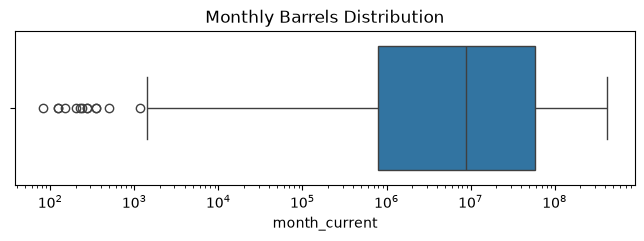

In [47]:
plt.figure(figsize=(8, 2))
plt.xscale('log')
sns.boxplot(x=materials['month_current'])
plt.title('Monthly Barrels Distribution')
plt.show()

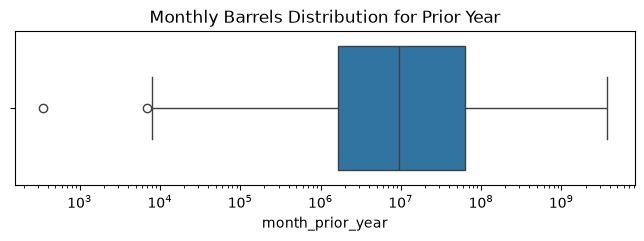

In [48]:
plt.figure(figsize=(8, 2))
plt.xscale('log')
sns.boxplot(x=materials['month_prior_year'])
plt.title('Monthly Barrels Distribution for Prior Year')
plt.show()

##### SUMMARY
- The values in `month_current` and `month_prior_year` are right-skewed.
- This means most values are smaller, but a few values are very large and stretch the distribution to the right.
- We can tell this from the summary statistics because the maximum values are much higher than the median and upper quartile.
- The boxplot may look slightly different because it is shown on a log scale, which compresses large values.
- These large values create outliers, but they may be genuine observations.
- So we should not remove them blindly.
- It is better to use log scale and compare values within groups like material type, year, or month.

#### 1.4.3 barrels

In [77]:
brewers.describe()

,year,total_barrels,taxable_removals,total_shipped,no_of_brewers
count,126.00,126.00,126.00,126.00,126.00
mean,2014.19,16620104.09,15356606.27,474241.79,332.90
std,3.19,40015541.55,37019011.20,1272265.33,805.76
min,2009.00,0.00,14711.36,0.00,3.00
25%,2011.25,1242285.11,1084831.39,4662.50,14.25
50%,2014.00,2457673.06,2261441.80,26526.50,41.00
75%,2017.00,7767164.11,6485478.16,107720.50,144.25
max,2019.00,171232881.59,159643984.23,5749122.00,4577.00


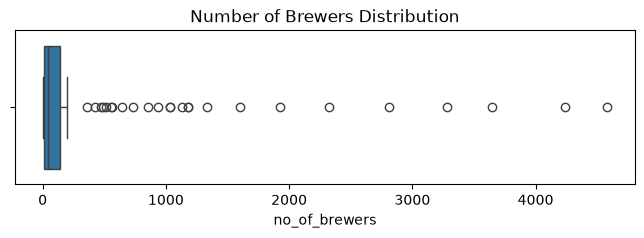

In [72]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=brewers['no_of_brewers'])
plt.title('Number of Brewers Distribution')
plt.show()

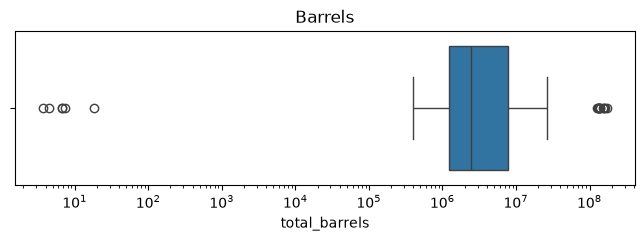

In [74]:
plt.figure(figsize=(8, 2))
plt.xscale('log')
sns.boxplot(x=brewers['total_barrels'])
plt.title('Barrels')
plt.show()

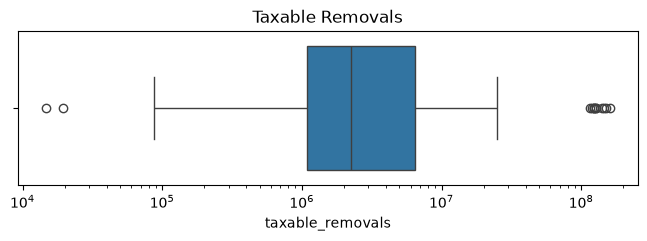

In [75]:
plt.figure(figsize=(8, 2))
plt.xscale('log')
sns.boxplot(x=brewers['taxable_removals'])
plt.title('Taxable Removals')
plt.show()

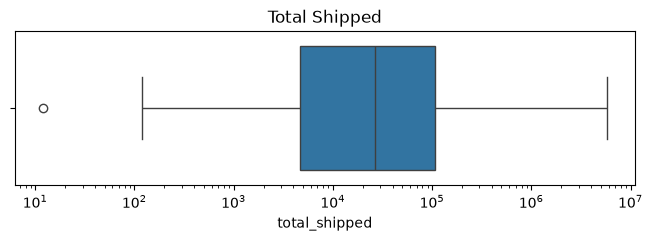

In [76]:
plt.figure(figsize=(8, 2))
plt.xscale('log')
sns.boxplot(x=brewers['total_shipped'])
plt.title('Total Shipped')
plt.show()

##### SUMMARY
- The outliers in this section look genuine and are likely caused by large differences in brewery size.
- `no_of_brewers` is highly right-skewed because most values are small, but a few values are very large.
- `total_barrels`, `taxable_removals`, and `total_shipped` also have very large values compared to the middle of the data.
- This shows that a small number of brewery groups contribute much more than the rest.
- These values should not be removed blindly because they may reflect real business differences.
- It is better to keep them and use log scale, median, IQR, and group-wise analysis for interpretation.

## **2** Performing Analyses
<font color = red>[100 marks]</font> <br>

### **2.1** *states*
<font color = red>[40 marks]</font>

**Univariate**

There is not much univariate analysis to perform here. You can find out the proportions of instances of different states and the production types (bottles and cans, kegs and barrels etc).

In [49]:
# Find the number of instances of each state in the data


**Multivariate**

**2.1.0**     <font color = red>[3 marks]</font> <br>
Coming to multivariate analyses, let us first classify the variables into categorical and numerical. Write below the type of variable, whether numerical or categorical and ordered or unordered:

* `state`:
* `year`:
* `barrels`:
* `type`:

Now, start with `states` vs `barrels`.

**2.1.1**     <font color = red>[5 marks]</font> <br>
Calculate the total and average beer production in barrels across all the years for each state. Also find the percentage share of every state in the total production.

In [50]:
# Find total beer production across all years, and the percentage share of each state in that




In [51]:
# Find the average beer production per year for all states




**2.1.2**     <font color = red>[3 marks]</font> <br>
Identify the top five and bottom five states and create a histogram showing their average production per year.

In [52]:
# Identify and visualise top 5 and bottom 5 states



**2.1.3**     <font color = red>[5 marks]</font> <br>
From the total production, visualise the proportion of the production type (kegs and barrels, bottles and cans etc.) Choose a suitable plot to show this information.

In [53]:
# Visualise the proportions of kegs, bottles and on premises production



**2.1.4**     <font color = red>[3 marks]</font> <br>
Get a description of mean, median, 1/4th and 3/4th quantiles etc for each production type. Compare the means of bottles/cans vs barrels/kegs vs on premises types.

In [54]:
# Describe mean, quantile values


**2.1.5**     <font color = red>[5 marks]</font> <br>
Create a heatmap of barrels produced by states across years.

In [55]:
# Create a heatmap of barrels produced by each state across the years



Now, let us analyse the trends in production.

**2.1.6**     <font color = red>[3 marks]</font> <br>
Visualise the variation in beer production across states throughout the years. You don't need to analyse for all the states. Take the top and bottom five.

In [56]:
# Visualise the trends in production for the most and least productive states



**2.1.7**     <font color = red>[5 marks]</font> <br>
Find the average growth rate per year for the top and bottom states. Do you find a common pattern? Which states are increasing and which states are declining?

In [57]:
# Calculate the average growth rates of the top and bottom states from the first year to the last year



**2.1.8**     <font color = red>[5 marks]</font> <br>
Analyse the trend of production types across years, irrespective of states. Identify which types are rising or declining or staying constant.

In [58]:
# Analyse the overall trend of production by production types (cans/barrels etc.)

**2.1.9**     <font color = red>[3 marks]</font> <br>
Now, for the top states, identify which types are rising across years and which are falling.

In [59]:
# Identify which production types are growing and which are declining



**2.1.10 Results**  
What are your inferences based on the analyses above? What did you find out about trends in production and about different states? Include your findings in the report.


If you want to analyse some more, you can do so below.

### **2.2** *materials*
<font color = red>[30 marks]</font>

In [60]:
# materials.columns.tolist()

**2.2.0**     <font color = red>[3 marks]</font> <br>
Write below the type of variable, whether numerical or categorical and ordered or unordered, like you did for *states*:

* `1`:
* `2`:
* `3`:
* `4`:
* `5`:

Yearwise production

**2.2.1**     <font color = red>[3 marks]</font> <br>
Calculate the yearwise production of beer from the various types of materials (grain-based and non-grain-based).

In [61]:
# Calculate the yearly production from grain and non grain materials



**2.2.2**     <font color = red>[4 marks]</font> <br>
Calculate the yearwise production of beer from the various materials (Barley, Malt, Hops etc).

In [62]:
# Calculate the yearly production from various ingredients



**2.2.3**     <font color = red>[5 marks]</font> <br>
Visualise the proportion of average production from various materials.
Create one visualisation for grain vs non-grain and one for the individual materials like barley, malt, hops etc.

In [63]:
# Visualise the distribution of average production from various materials and ingredients



**2.2.4**     <font color = red>[5 marks]</font> <br>
What has changed in 10 years? <br>
Create a visualisation to show trends in the use of materials in 2008 vs 2017. Show how the use of grains and non-grain based materials vary over months in 2008 and 2017.

In [64]:
# Visualise the monthly trends of usage of grain and non grain materials in 2008 vs 2017



**2.2.5**     <font color = red>[5 marks]</font> <br>
Now, for the above visualisation, instead of simply using production quantity, use the difference in current month's production and the production in current month in the prior year.

How did 2008 perform compared to 2007? What about 2017 compared to 2016?

This can be used to identify the months when production is increased seasonally. <br>
For example, if we see that the production in a month is especially high, we can check the difference in production for that month in current year and last year.<br>
If the difference comes out to be small, we can say that the production rises every year in that month. If the difference is large, probably that month was unusualy productive!

**2.2.6**     <font color = red>[5 marks]</font> <br>

So, what do you infer based on the two visualisations above?

**2.2.7 Results**    
Include your insights in the report. What are your inferences on use of different materials across months, production trends and overall material preferences?

### **2.3** brewers
<font color = red>[30 marks]</font> <br>

**2.3.0**     <font color = red>[3 marks]</font> <br>
Write below the type of variable, whether numerical or categorical and ordered or unordered, like you did previously:

* `1`:
* `2`:
* `3`:
* `4`:
* `5`:

**2.3.1**     <font color = red>[5 marks]</font> <br>
Analyze the distribution of brewers by size over time. Are small or large brewers more prevalent in specific years?


In [65]:
# Analyse the distribution of brewer sizes over time



**2.3.2**     <font color = red>[5 marks]</font> <br>
How does their contribution to total beer production change over time?

In [66]:
# Analyse the contribution of different brewer sizes to the total production over the years



**2.3.3**     <font color = red>[7 marks]</font> <br>
Investigate the correlation between brewer size and taxable removals. Do larger brewers produce more taxable beer compared to smaller brewers? Also find the correlation value.

In [67]:
# Find correlation between brewer size and taxable removals
# Note that brewer size is categorical



**2.3.4**     <font color = red>[5 marks]</font> <br>
Visualise `total_shipped` over time to see how the volume of shipped beer fluctuates across different brewer sizes.

In [68]:
# Visualise the trends in quantities of shipped beer across different brewer sizes



**2.3.5**     <font color = red>[5 marks]</font> <br>
Can you connect consumption with shipped and taxed beer? What did you find out about the distribution of brewers based on their size in the USA?

**2.3.6 Results**

What are your inferences based on the above analyses? Include all your findings in the report.

## **3** Conclusion
<font color = red>[10 marks]</font> <br>

### **3.1** Final Insights and Recommendations
<font color = red>[10 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found and propose recommendations about different states, brewery sizes and materials suited for production.

Based on your insights, frame a concluding story explaining suitable parameters such as location, size, etc. to be kept in mind while setting up a brewery.

**3.1.0**     <font color = red>[2 marks]</font> <br>
Which material type (malt, corn, rice, barley etc) has the has the highest percentage of current number of barrels for this year/month? Which material type has the least percentage of current number of barrels for this year/month?

**3.1.1**     <font color = red>[2 marks]</font> <br>
In which year and for which brewer size, the total taxable removals were greater than the total barrels of beer produced

**3.1.2**     <font color = red>[2 marks]</font> <br>
What is the average production per year of the top 5 states and the bottom 5 states?  

**3.1.3**     <font color = red>[2 marks]</font> <br>
For which year, the On Premises production was highest and for which state? For which year it is the lowest and for which state?

**3.1.4**     <font color = red>[2 marks]</font> <br>
Which state has a positive year on year growth rate for most of the years starting from 2008 to 2018? Which state has a negative growth rate year on year most of the years?